# 03b — Siamese signature verification with a fine-tuned EfficientNet-B0

Same protocol as notebook 3 (writer-independent split, leak-free 3-recipe pairs, triplet
loss, signature-appropriate augmentation, per-script + NFI cross-dataset eval) — but the
hand-built SigNet tower is replaced by a **fine-tuned EfficientNet-B0** backbone.

**Why this is an honest experiment, not a guaranteed win.** The old NB3 *froze* a MobileNetV2
backbone and lost to the from-scratch tower (ImageNet features don't fit thin pen strokes). This
re-tests that hypothesis **fairly**: we *fine-tune* the whole backbone (its real strength), not
freeze it. It may still lose to NB3 — that itself is a useful finding.

**What carries over from NB3 (the parts that actually helped):**
- Writer-independent split, leak-free 3-recipe pairs, **triplet loss** (margin 0.3).
- SigNet **invert** preprocessing — ink becomes the signal, white page → 0 (see image-pipeline cell).
- Signature-appropriate augmentation (small affine, **no flips**), combined Latin+Devanagari set,
  per-script + NFI cross-dataset evaluation, decoded-image caching.

**What changed vs NB3 (simpler on purpose):**
- EfficientNet-B0 already has **SE attention built in** → we drop NB3's custom SE block and LRN.
- `GlobalAveragePooling → Dense(128)` replaces NB3's `Flatten → Dense(1024)` (that one layer was
  ~111M params / 521 MB). New model ≈ **4M params (~17 MB)**.
- **Drive checkpoint every epoch** so a Colab free-tier disconnect can resume.
- 3-channel input + Adam fine-tuning LR (1e-4); we keep invert but drop SigNet's ÷std, since
  EfficientNet normalizes internally and a second normalization would break its input range.

In [1]:
import os, json, math, random, csv
from collections import defaultdict
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import tensorflow as tf
from keras import layers, Model
from keras.layers import Input, Dense, Dropout, Lambda, GlobalAveragePooling2D
from keras.applications import EfficientNetB0
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import roc_auc_score, roc_curve

## Data — same combined Latin + Devanagari set and writer-independent split as NB3

In [2]:
!git clone https://github.com/goyashek/Signature-forgery-verification.git

DATA_ROOT = 'Signature-forgery-verification/sign_data_combined'
if not os.path.isdir(DATA_ROOT):                      # running locally, not on Colab
    DATA_ROOT = 'sign_data_combined'
MANIFEST = os.path.join(DATA_ROOT, 'manifest.csv')

# EfficientNet is fully convolutional (ends in global pooling), so it accepts NB3's size.
# We keep 155x220 to stay comparable with NB3 and light on GPU memory.
IMG_H, IMG_W = 155, 220
print('data root:', DATA_ROOT)

Cloning into 'Signature-forgery-verification'...
remote: Enumerating objects: 12893, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 12893 (delta 6), reused 8 (delta 6), pack-reused 12874 (from 1)
Receiving objects: 100% (12893/12893), 336.83 MiB | 18.80 MiB/s, done.
Resolving deltas: 100% (54/54), done.
Updating files: 100% (12755/12755), done.
data root: Signature-forgery-verification/sign_data_combined


In [3]:
rows = list(csv.DictReader(open(MANIFEST)))

genuine, forg = defaultdict(list), defaultdict(list)
script_of = {}                                        # writer -> 'latin' | 'devanagari'
for r in rows:
    (genuine if r['kind'] == 'genuine' else forg)[r['writer']].append(r['relpath'])
    script_of[r['writer']] = r['script']

writers = sorted(set(genuine) & set(forg))
icdar = [w for w in writers if w.startswith('icdar_')]
bhh   = [w for w in writers if w.startswith('bhh_')]
num   = lambda w: int(w.split('_')[1])

train_w = [w for w in icdar if num(w) <= 40]        + [w for w in bhh if num(w) <= 110]
val_w   = [w for w in icdar if 41 <= num(w) <= 48]  + [w for w in bhh if 111 <= num(w) <= 130]
test_w  = [w for w in icdar if num(w) >= 49]        + [w for w in bhh if num(w) >= 131]

assert not (set(train_w) & set(val_w)), 'train/val writer leak'
assert not (set(train_w) & set(test_w)), 'train/test writer leak'
assert not (set(val_w) & set(test_w)), 'val/test writer leak'

def _c(ws): return f"{len(ws)} (icdar {sum(w.startswith('icdar_') for w in ws)} + bhh {sum(w.startswith('bhh_') for w in ws)})"
print('train:', _c(train_w))
print('val:  ', _c(val_w))
print('test: ', _c(test_w))

train: 145 (icdar 35 + bhh 110)
val:   28 (icdar 8 + bhh 20)
test:  51 (icdar 21 + bhh 30)


## Leak-free pairs / triplets — identical recipe to NB3

Triplets for training (anchor = genuine of A, positive = another genuine of A, negative =
a forgery of A **or** a genuine of a different writer B). Evaluation uses pairs with the
3-recipe leak-free mix so `img2` never reveals the label.

In [4]:
def make_triplets(wset, per_writer, seed=42):
    rng = random.Random(seed); wl = sorted(wset); out = []
    for w in wl:
        g = genuine[w]
        if len(g) < 2:
            continue
        for _ in range(per_writer):
            a, p = rng.sample(g, 2)
            if rng.random() < 0.5 and forg.get(w):                 # hard negative: forgery of w
                n = rng.choice(forg[w])
            else:                                                  # random negative: other writer
                other = rng.choice([x for x in wl if x != w])
                n = rng.choice(genuine[other])
            out.append((a, p, n))
    rng.shuffle(out)
    return pd.DataFrame(out, columns=['a', 'p', 'n'])

def make_pairs(wset, per_writer, seed=1):
    rng = random.Random(seed); wl = sorted(wset); out = []
    for w in wl:
        g = genuine[w]
        if len(g) < 2:
            continue
        scr = script_of[w]
        for _ in range(per_writer):                                # match (0)
            a, b = rng.sample(g, 2); out.append((a, b, 0, scr))
        for _ in range(per_writer // 2):                           # forgery negative (1)
            if forg.get(w):
                out.append((rng.choice(g), rng.choice(forg[w]), 1, scr))
        for _ in range(per_writer // 2):                           # different-writer negative (1)
            other = rng.choice([x for x in wl if x != w])
            out.append((rng.choice(g), rng.choice(genuine[other]), 1, scr))
    rng.shuffle(out)
    return pd.DataFrame(out, columns=['img1', 'img2', 'label', 'script'])

tri_train = make_triplets(train_w, per_writer=40)
pairs_val = make_pairs(val_w,  per_writer=40, seed=2)
pairs_test = make_pairs(test_w, per_writer=40, seed=3)
print('train triplets:', len(tri_train))
print('val pairs:', len(pairs_val), '| test pairs:', len(pairs_test))
print('test by script:', pairs_test['script'].value_counts().to_dict())

train triplets: 5800
val pairs: 2240 | test pairs: 4080
test by script: {'devanagari': 2400, 'latin': 1680}


## Image pipeline

The model input is **3-channel** (EfficientNet-B0 expects RGB and normalizes internally on a
`[0,255]` range). We keep SigNet's **invert** step — `255 - pixel`, so the **ink becomes the
signal and the white page → 0** — then replicate the inverted grayscale across the 3 channels.
This is the one signature-domain preprocessing choice that the project's results say matters;
dropping it would re-introduce the generic "treat it like a natural photo" assumption that sank
the old frozen-MobileNet NB3.

We do **not** also apply SigNet's ÷std: EfficientNet already does its own normalization, so a
second one would double-normalize and break the backbone's expected input range. Invert gives
us the domain signal; EfficientNet handles the scaling.

The small affine augmentation (rotation ±5°, shift ≤6%, zoom ±10%, white fill; **no flips**) is
unchanged from NB3. Decoded images are cached as uint8 so epochs after the first do no disk I/O.

In [5]:
_CACHE = {}                                            # relpath -> decoded uint8 grayscale (bg=255)

def load_gray(relpath):
    im = _CACHE.get(relpath)
    if im is None:
        im = cv2.imread(os.path.join(DATA_ROOT, relpath), cv2.IMREAD_GRAYSCALE)
        im = cv2.resize(im, (IMG_W, IMG_H))
        _CACHE[relpath] = im
    return im

def augment(im, rng):
    ang  = rng.uniform(-5, 5)
    tx   = rng.uniform(-0.06, 0.06) * IMG_W
    ty   = rng.uniform(-0.06, 0.06) * IMG_H
    zoom = rng.uniform(0.9, 1.1)
    M = cv2.getRotationMatrix2D((IMG_W / 2, IMG_H / 2), ang, zoom)
    M[0, 2] += tx; M[1, 2] += ty
    return cv2.warpAffine(im, M, (IMG_W, IMG_H), borderValue=255)   # white fill = background

def to3(im):
    """uint8 HxW grayscale -> inverted float32 HxWx3 in [0,255].

    SigNet invert: 255 - pixel, so ink (was dark) becomes the high-signal and the white
    page -> 0. EfficientNet then normalizes this internally, so we do NOT add SigNet's
    /std (that would double-normalize). Replicate the inverted gray across 3 channels.
    """
    inv = 255.0 - im.astype('float32')
    return np.repeat(inv[..., None], 3, axis=2)

class TripletSequence(tf.keras.utils.Sequence):
    def __init__(self, frame, batch_size=32, shuffle=True, do_aug=True, seed=0):
        try:    super().__init__(workers=4, use_multiprocessing=False, max_queue_size=12)
        except TypeError: super().__init__()
        self.f = frame.reset_index(drop=True); self.bs = batch_size
        self.shuffle = shuffle; self.do_aug = do_aug
        self.idx = np.arange(len(self.f)); self.rng = random.Random(seed)
        self.on_epoch_end()
    def __len__(self): return math.ceil(len(self.f) / self.bs)
    def on_epoch_end(self):
        if self.shuffle: np.random.shuffle(self.idx)
    def _prep(self, relpath):
        im = load_gray(relpath)
        if self.do_aug: im = augment(im, self.rng)
        return to3(im)
    def __getitem__(self, i):
        b = self.idx[i*self.bs:(i+1)*self.bs]; sub = self.f.iloc[b]
        A = np.stack([self._prep(p) for p in sub['a']])
        P = np.stack([self._prep(p) for p in sub['p']])
        N = np.stack([self._prep(p) for p in sub['n']])
        return (A, P, N), np.zeros(len(sub), dtype='float32')

class PairSequence(tf.keras.utils.Sequence):
    """Eval only: yields (X1, X2); never augments. shuffle=False keeps predict aligned."""
    def __init__(self, frame, batch_size=32, root=DATA_ROOT):
        try:    super().__init__(workers=4, use_multiprocessing=False, max_queue_size=12)
        except TypeError: super().__init__()
        self.f = frame.reset_index(drop=True); self.bs = batch_size; self.root = root
    def __len__(self): return math.ceil(len(self.f) / self.bs)
    def _prep(self, relpath):
        im = cv2.imread(os.path.join(self.root, relpath), cv2.IMREAD_GRAYSCALE)
        im = cv2.resize(im, (IMG_W, IMG_H))
        return to3(im)
    def __getitem__(self, i):
        sub = self.f.iloc[i*self.bs:(i+1)*self.bs]
        X1 = np.stack([self._prep(p) for p in sub['img1']])
        X2 = np.stack([self._prep(p) for p in sub['img2']])
        return (X1, X2)

BATCH = 32
train_gen = TripletSequence(tri_train, batch_size=BATCH, shuffle=True, do_aug=True)
print('train batches:', len(train_gen))

train batches: 182


## The embedding tower — fine-tuned EfficientNet-B0

`include_top=False, pooling='avg'` gives a 1280-d vector; a single `Dense(128)` + L2-normalize
makes the embedding. The backbone is **trainable** (fine-tuned) — the key difference from the
old frozen-MobileNet NB3. EfficientNet's built-in SE blocks cover the "attention" idea, so
there's no custom attention code here.

In [6]:
def l2(t): return tf.math.l2_normalize(t, axis=1)

def build_tower():
    base = EfficientNetB0(include_top=False, weights='imagenet',
                          input_shape=(IMG_H, IMG_W, 3), pooling='avg')
    base.trainable = True                              # fine-tune (old NB3 froze this -> underperformed)
    inp = Input(shape=(IMG_H, IMG_W, 3))
    x = base(inp)                                      # (B, 1280)
    x = Dropout(0.3)(x)
    x = Dense(128)(x)
    x = Lambda(l2, name='l2')(x)
    return Model(inp, x, name='tower')

tower = build_tower()
tower.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "tower"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 155, 220, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l2 (Lambda)                     │ (None, 128)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,539 (16.07 MB)

 Trainable params: 4,171,516 (15.91 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [7]:
MARGIN = 0.3

in_a = Input(shape=(IMG_H, IMG_W, 3))
in_p = Input(shape=(IMG_H, IMG_W, 3))
in_n = Input(shape=(IMG_H, IMG_W, 3))
emb_a, emb_p, emb_n = tower(in_a), tower(in_p), tower(in_n)
stacked = Lambda(lambda t: tf.stack(t, axis=1), name='triplet')([emb_a, emb_p, emb_n])  # (B,3,128)
triplet_model = Model([in_a, in_p, in_n], stacked)

def triplet_loss(_, y_pred):
    a, p, n = y_pred[:, 0], y_pred[:, 1], y_pred[:, 2]
    d_ap = tf.reduce_sum(tf.square(a - p), axis=1)
    d_an = tf.reduce_sum(tf.square(a - n), axis=1)
    return tf.reduce_mean(tf.maximum(d_ap - d_an + MARGIN, 0.0))

# Adam @ 1e-4 is the standard gentle LR for fine-tuning a pretrained backbone (vs SigNet's RMSprop,
# which suited training from scratch). Keeps the ImageNet weights from being wrecked early.
triplet_model.compile(optimizer=Adam(1e-4), loss=triplet_loss)
print('trainable params:', f"{int(np.sum([np.prod(v.shape) for v in triplet_model.trainable_weights])):,}")

trainable params: 4,171,516


## Checkpoint to Drive, then train (Colab free-tier safe)

Colab free tier disconnects often, so we save the weights to Google Drive **every epoch**. If
the runtime dies, just re-run all cells up to here: the checkpoint is reloaded and training
continues. (Weights-only keeps the write fast and dodges custom-loss serialization issues.)

To resume from a specific epoch, set `INITIAL_EPOCH` to the last completed epoch before
re-running the fit cell. Leaving it at 0 is fine — `EarlyStopping(restore_best_weights=True)`
still recovers the best model.

In [8]:
from google.colab import drive
drive.mount('/content/drive')

CKPT_DIR = '/content/drive/MyDrive/sigver_nb3b'
os.makedirs(CKPT_DIR, exist_ok=True)
CKPT = os.path.join(CKPT_DIR, 'triplet_3b.weights.h5')

if os.path.exists(CKPT):
    triplet_model.load_weights(CKPT)
    print('resumed weights from', CKPT)
else:
    print('no checkpoint yet — training from ImageNet init')

Mounted at /content/drive
no checkpoint yet — training from ImageNet init


In [9]:
INITIAL_EPOCH = 0        # set to last completed epoch when resuming after a disconnect
EPOCHS = 30

checkpoint = ModelCheckpoint(CKPT, save_weights_only=True, save_freq='epoch', verbose=1)
early_stop = EarlyStopping(monitor='loss', patience=6, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor='loss', factor=0.5, patience=3, verbose=1)

history = triplet_model.fit(train_gen, epochs=EPOCHS, initial_epoch=INITIAL_EPOCH,
                            callbacks=[checkpoint, early_stop, reduce_lr])

Epoch 1/30
182/182 ━━━━━━━━━━━━━━━━━━━━ 0s 734ms/step - loss: 0.1524
Epoch 1: saving model to /content/drive/MyDrive/sigver_nb3b/triplet_3b.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/sigver_nb3b/triplet_3b.weights.h5
182/182 ━━━━━━━━━━━━━━━━━━━━ 290s 744ms/step - loss: 0.1276 - learning_rate: 1.0000e-04
Epoch 2/30
182/182 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - loss: 0.0751
Epoch 2: saving model to /content/drive/MyDrive/sigver_nb3b/triplet_3b.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/sigver_nb3b/triplet_3b.weights.h5
182/182 ━━━━━━━━━━━━━━━━━━━━ 57s 310ms/step - loss: 0.0664 - learning_rate: 1.0000e-04
Epoch 3/30
182/182 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - loss: 0.0466
Epoch 3: saving model to /content/drive/MyDrive/sigver_nb3b/triplet_3b.weights.h5

Epoch 3: finished saving model to /content/drive/MyDrive/sigver_nb3b/triplet_3b.weights.h5
182/182 ━━━━━━━━━━━━━━━━━━━━ 56s 303ms/step - loss: 0.0443 - learning_rate: 1.0000e-04
Epoch 4/3

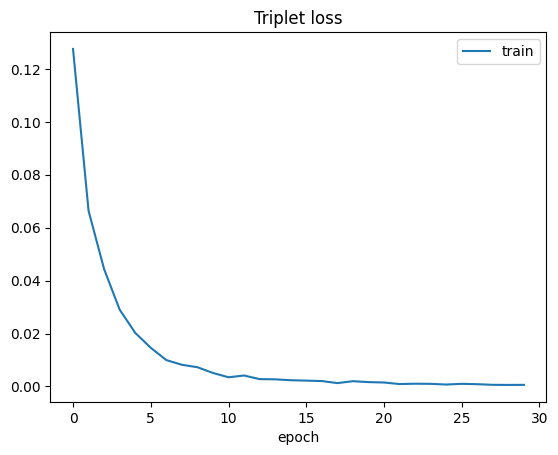

In [10]:
plt.plot(history.history['loss'], label='train')
plt.title('Triplet loss'); plt.xlabel('epoch'); plt.legend(); plt.show()

## Evaluation — EER threshold on validation, then held-out test (identical to NB3)

In [11]:
def pair_distances(frame, root=DATA_ROOT):
    gen = PairSequence(frame, batch_size=64, root=root)
    e1, e2 = [], []
    for i in range(len(gen)):
        X1, X2 = gen[i]
        e1.append(tower.predict(X1, verbose=0))
        e2.append(tower.predict(X2, verbose=0))
    e1 = np.concatenate(e1); e2 = np.concatenate(e2)
    return np.sqrt(np.sum((e1 - e2) ** 2, axis=1) + 1e-12)

val_d = pair_distances(pairs_val)
y_va  = pairs_val['label'].to_numpy()
fpr, tpr, thr = roc_curve(y_va, val_d); fnr = 1 - tpr
eer_idx = np.nanargmin(np.abs(fpr - fnr))
threshold = float(thr[eer_idx])
print('threshold:', round(threshold, 4))
print('val EER:  ', round(float((fpr[eer_idx] + fnr[eer_idx]) / 2) * 100, 2), '%')
print('val AUC:  ', round(roc_auc_score(y_va, val_d), 3))

threshold: 0.8355
val EER:   12.5 %
val AUC:   0.953


In [12]:
test_d = pair_distances(pairs_test)
y_te   = pairs_test['label'].to_numpy()
scr_te = pairs_test['script'].to_numpy()

def report(name, d, y):
    if len(y) == 0 or len(np.unique(y)) < 2:
        print(f'{name:12s} — not enough data'); return
    pred = (d > threshold).astype(int)
    print(f'{name:12s} | n={len(y):5d} | AUC {roc_auc_score(y, d):.3f} | '
          f'acc {100*(pred==y).mean():5.2f}% | '
          f'FAR {100*(d[y==1] < threshold).mean():5.2f}% | '
          f'FRR {100*(d[y==0] > threshold).mean():5.2f}%')

print('held-out test (threshold fixed on val):')
report('overall',    test_d, y_te)
report('Latin',      test_d[scr_te == 'latin'],      y_te[scr_te == 'latin'])
report('Devanagari', test_d[scr_te == 'devanagari'], y_te[scr_te == 'devanagari'])

held-out test (threshold fixed on val):
overall      | n= 4080 | AUC 0.941 | acc 86.35% | FAR  9.85% | FRR 17.45%
Latin        | n= 1680 | AUC 0.957 | acc 80.89% | FAR  3.57% | FRR 34.64%
Devanagari   | n= 2400 | AUC 0.968 | acc 90.17% | FAR 14.25% | FRR  5.42%


### Per-script thresholds (calibration, no retraining)

The single global EER threshold is a compromise across two scripts with different natural
spread, which is why Latin over-rejects genuine signatures (high FRR) while Devanagari is
balanced. Here we calibrate a **separate EER threshold per script on the validation set**, then
apply each to that script's **test** pairs. Same model, same distances — only the operating
point moves, so **AUC is unchanged**; this trades the FAR/FRR balance into a better place.

Thresholds come from *validation only* (no test-set peeking). In real deployment the
per-writer version (calibrate on a writer's enrollment samples) is stronger still, but needs
enrollment data; per-script is the zero-extra-data version of the same idea.

In [ ]:
# per-script EER threshold from VALIDATION, applied to TEST (no retraining, no test peeking)
scr_va = pairs_val['script'].to_numpy()

def eer_threshold(d, y):
    fpr, tpr, thr = roc_curve(y, d); fnr = 1 - tpr
    i = np.nanargmin(np.abs(fpr - fnr))
    return float(thr[i]), float((fpr[i] + fnr[i]) / 2)

per_script_thr = {}
for scr in ['latin', 'devanagari']:
    m = scr_va == scr
    t, e = eer_threshold(val_d[m], y_va[m])
    per_script_thr[scr] = t
    print(f'{scr:11s} val threshold {t:.4f}  (val EER {e*100:.2f}%)')

def report_t(name, d, y, t):
    if len(y) == 0 or len(np.unique(y)) < 2:
        print(f'{name:12s} \u2014 not enough data'); return
    pred = (d > t).astype(int)
    print(f'{name:12s} | n={len(y):5d} | AUC {roc_auc_score(y, d):.3f} | '
          f'acc {100*(pred==y).mean():5.2f}% | '
          f'FAR {100*(d[y==1] < t).mean():5.2f}% | '
          f'FRR {100*(d[y==0] > t).mean():5.2f}%')

print('\nheld-out test (per-script thresholds from val):')
for scr in ['latin', 'devanagari']:
    m = scr_te == scr
    report_t(scr.capitalize(), test_d[m], y_te[m], per_script_thr[scr])

# overall: each test pair judged against its own script's threshold
thr_vec = np.array([per_script_thr[s] for s in scr_te])
pred = (test_d > thr_vec).astype(int)
print(f'{"overall*":12s} | n={len(y_te):5d} | '
      f'acc {100*(pred==y_te).mean():5.2f}% | '
      f'FAR {100*(test_d[y_te==1] < thr_vec[y_te==1]).mean():5.2f}% | '
      f'FRR {100*(test_d[y_te==0] > thr_vec[y_te==0]).mean():5.2f}%')
print('(*overall AUC is unchanged from the global-threshold cell \u2014 only the operating point moved)')

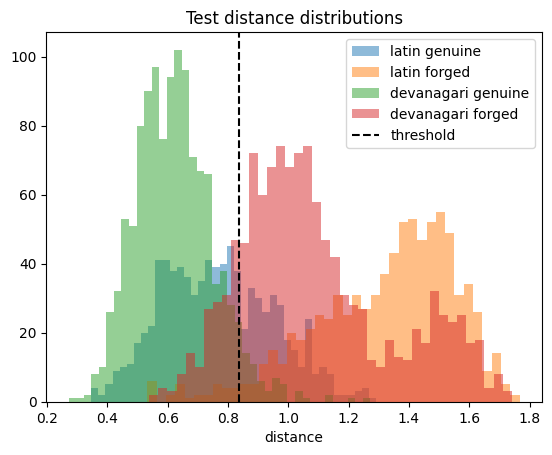

In [13]:
for scr in ['latin', 'devanagari']:
    m = scr_te == scr
    plt.hist(test_d[m & (y_te==0)], bins=40, alpha=0.5, label=f'{scr} genuine')
    plt.hist(test_d[m & (y_te==1)], bins=40, alpha=0.5, label=f'{scr} forged')
plt.axvline(threshold, color='k', ls='--', label='threshold')
plt.xlabel('distance'); plt.legend(); plt.title('Test distance distributions'); plt.show()

## Save the embedding tower + meta (for the Streamlit app)

In [14]:
tower.save('siamese_effnet_embedding.keras')
json.dump({'threshold': threshold, 'img_h': IMG_H, 'img_w': IMG_W,
           'preprocess': 'invert_gray3ch', 'channels': 3,
           'model': 'siamese_efficientnet_b0_triplet'},
          open('siamese_effnet_meta.json', 'w'))
print('saved tower + meta')

saved tower + meta


## NFI cross-dataset test — the one apples-to-apples comparison vs NB2 / NB3

In [15]:
import glob, re

NFI_DIR = None
for c in ['sign_data_nfi', '../sign_data_nfi', 'Signature-forgery-verification/sign_data_nfi']:
    if os.path.isdir(c):
        NFI_DIR = c; break

if NFI_DIR is None:
    print('sign_data_nfi not found — skipping cross-dataset test.')
else:
    def _parse(fn):                       # NFI-XXXYYZZZ -> (signer, owner); genuine iff signer==owner
        s = re.sub(r'^NFI-', '', os.path.basename(fn)); s = os.path.splitext(s)[0]
        return (s[:3], s[5:8]) if re.fullmatch(r'\d{8}', s) else None

    nfi_gen, nfi_forg = defaultdict(list), defaultdict(list)
    for f in glob.glob(os.path.join(NFI_DIR, 'genuine', '*')):
        p = _parse(f); nfi_gen[p[1]].append(f) if p else None
    for f in glob.glob(os.path.join(NFI_DIR, 'forged', '*')):
        p = _parse(f); nfi_forg[p[1]].append(f) if p else None
    owners = sorted(set(nfi_gen) & set(nfi_forg), key=int)

    rng = random.Random(7); nrows = []
    for o in owners:
        g = nfi_gen[o]
        if len(g) < 2: continue
        for _ in range(40):
            a, b = rng.sample(g, 2); nrows.append((a, b, 0))
        for _ in range(20):
            if nfi_forg.get(o): nrows.append((rng.choice(g), rng.choice(nfi_forg[o]), 1))
        for _ in range(20):
            other = rng.choice([x for x in owners if x != o])
            nrows.append((rng.choice(g), rng.choice(nfi_gen[other]), 1))
    rng.shuffle(nrows)
    nfi_df = pd.DataFrame(nrows, columns=['img1', 'img2', 'label'])
    ny = nfi_df['label'].to_numpy()

    nd = pair_distances(nfi_df, root='')              # NFI globs resolve from cwd, not DATA_ROOT
    nauc = roc_auc_score(ny, nd)
    fpr, tpr, thr = roc_curve(ny, nd); fnr = 1 - tpr
    i = np.nanargmin(np.abs(fpr - fnr)); nfi_eer = (fpr[i] + fnr[i]) / 2
    pred = (nd > threshold).astype(int)
    print('NFI:', len(owners), 'owners |', len(nfi_df), 'pairs')
    print('--- cross-dataset (trained on combined, tested on NFI) ---')
    print('ROC-AUC                  :', round(nauc, 3))
    print('EER (recalibrated on NFI):', round(nfi_eer * 100, 2), '%')
    print('at combined threshold    -> acc', round(100*(pred==ny).mean(), 2),
          '% | FAR', round(100*(nd[ny==1] < threshold).mean(), 2),
          '% | FRR', round(100*(nd[ny==0] > threshold).mean(), 2), '%')

NFI: 30 owners | 2400 pairs
--- cross-dataset (trained on combined, tested on NFI) ---
ROC-AUC                  : 0.871
EER (recalibrated on NFI): 21.29 %
at combined threshold    -> acc 77.71 % | FAR 40.33 % | FRR 4.25 %
